In [1]:
import pandas as pd
import numpy as np

In [2]:
nvidia = pd.read_csv('nvidia_with_features.csv')

#### Removing unnecessary features

In [3]:
drop_cols = ['MACD_Histogram']
nvidia.drop(columns=drop_cols, inplace=True)

In [4]:
nvidia['BB_Width'] = nvidia['Upper_Band'] - nvidia['Lower_Band']

In [5]:
drop_cols = ['Upper_Band', 'Lower_Band']
nvidia.drop(columns=drop_cols, inplace=True)

In [6]:
drop_cols = ['Open', 'High', 'Low']
nvidia.drop(columns=drop_cols, inplace=True)

In [8]:
nvidia.shape

(6796, 19)

In [7]:
nvidia['Lag_R1'] = nvidia['Returns'].shift(1)
nvidia['Lag_R2'] = nvidia['Returns'].shift(2)

## MACHINE LEARNING

In [9]:
nvidia['Target'] = nvidia['Close'].shift(-1)

In [10]:
nvidia = nvidia.dropna()

In [11]:
features = [
    'Close',
    'Volume',
    'Returns',
    'Volatility',
    'RSI',
    'MACD',
    'Signal_Line',
    'Momentum',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_5',
    'Volume_Change',
    'Volume_MA20'
]

target = 'Target'

In [12]:
X = nvidia[features]
y = nvidia[target]

### Train Test Split

In [13]:
from sklearn.model_selection import train_test_split

split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

Shuffle = False is must because time order matter in Stock Market Data

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression Model

In [15]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
lr_pred = lr_model.predict(X_test_scaled)

lr_pred[:5], y_test[:5]

(array([12.20535533, 12.78948992, 13.06535364, 12.63118144, 12.4703343 ]),
 5445    12.832362
 5446    12.950743
 5447    12.475720
 5448    12.424880
 5449    12.151476
 Name: Target, dtype: float64)

In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = mean_squared_error(
    y_test,
    lr_pred
) ** 0.5

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

Linear Regression Results
MAE: 1.4419201172468612
RMSE: 2.4716233576340527
R²: 0.9982143831758757


## Random Forrest Regressor Model

In [18]:
nvidia['Target'] = nvidia['Returns'].shift(-1)

In [19]:
nvidia = nvidia.dropna()

In [20]:
features = [
    'Close',
    'Volume',
    'Returns',
    'Volatility',
    'RSI',
    'MACD',
    'Momentum',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_5',
    'Volume_Change',
    'Volume_MA20'
]

target = 'Target'

In [21]:
X = nvidia[features]
y = nvidia[target]

In [22]:
from sklearn.model_selection import train_test_split

split = int(len(nvidia) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
rf_pred = rf_model.predict(X_test)

In [25]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Results
MAE: 0.02734999717086743
RMSE: 0.035796460572754284
R²: -0.2278784942439387


### -Returns should be predicted instead of Closing price in Random Forrest in case of Stocks

## XGBoost Regressor Model

In [26]:
nvidia['Target'] = nvidia['Returns'].shift(-1)

In [27]:
nvidia = nvidia.dropna()

In [28]:
features = [
    'Close',
    'Volume',
    'Returns',
    'Volatility',
    'RSI',
    'MACD',
    'Momentum',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_5',
    'Lag_R1',
    'Lag_R2',
    'Volume_Change',
    'Volume_MA20'
]

target = 'Target'

In [29]:
X = nvidia[features]
y = nvidia[target]

In [30]:
from sklearn.model_selection import train_test_split

split = int(len(nvidia) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [31]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
xgb_pred = xgb_model.predict(X_test)

In [33]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = mean_squared_error(
    y_test,
    xgb_pred
) ** 0.5

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

XGBoost Results
MAE: 0.028397833290489293
RMSE: 0.037824549261379084
R²: -0.3708182157634192


### Comparing Models

In [34]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    'R2 Score': [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  1.441920  2.471623  0.998214
1      Random Forest  0.027350  0.035796 -0.227878
2            XGBoost  0.028398  0.037825 -0.370818


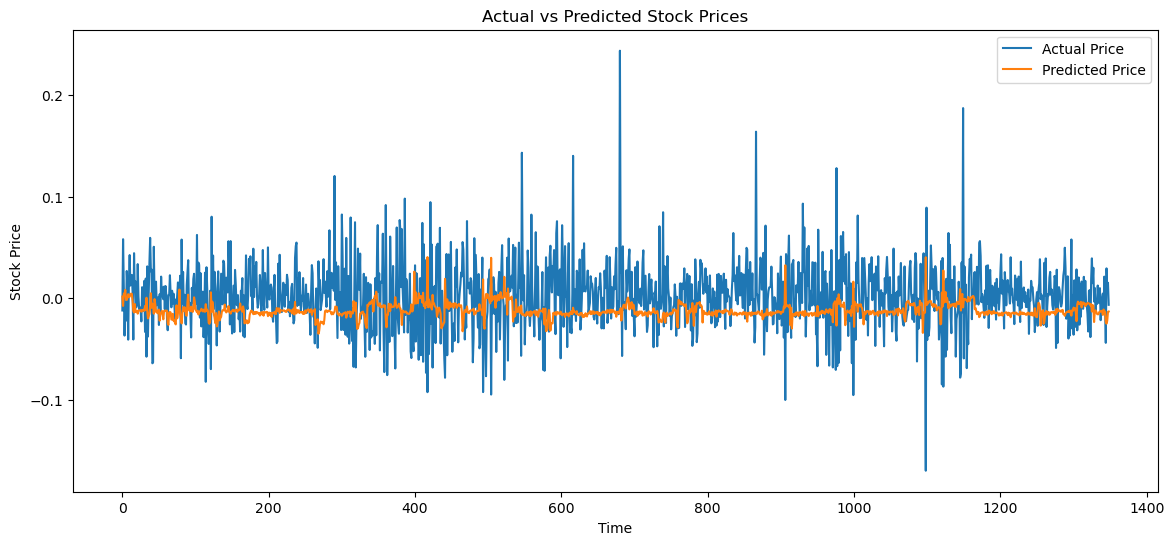

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label='Actual Price'
)

plt.plot(
    rf_pred,
    label='Predicted Price'
)

plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Time')
plt.ylabel('Stock Price')

plt.legend()

plt.show()

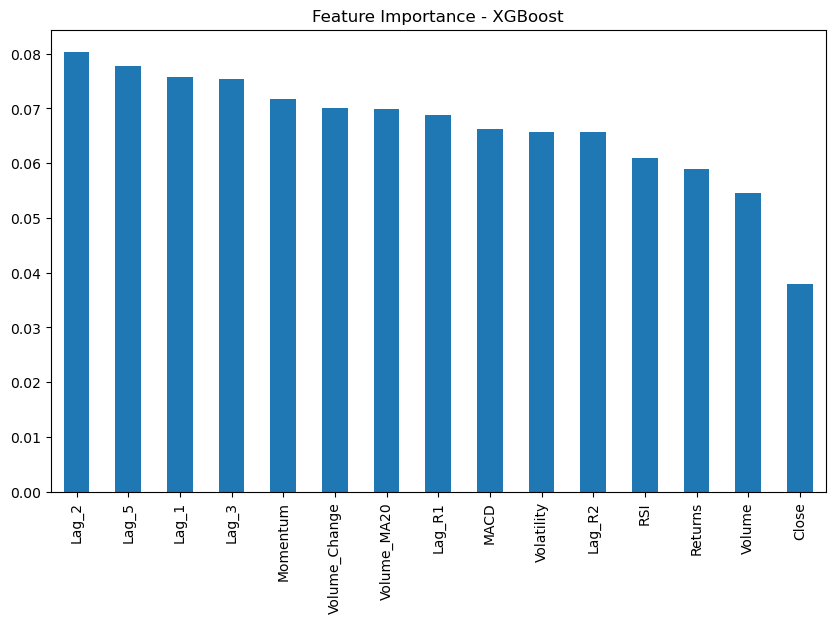

In [40]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.plot(kind='bar')

plt.title('Feature Importance - XGBoost')

plt.show()

In [41]:
nvidia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6744 entries, 49 to 6792
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close          6744 non-null   float64
 1   Volume         6744 non-null   int64  
 2   Returns        6744 non-null   float64
 3   MA20           6744 non-null   float64
 4   MA50           6744 non-null   float64
 5   Volatility     6744 non-null   float64
 6   RSI            6744 non-null   float64
 7   MACD           6744 non-null   float64
 8   Signal_Line    6744 non-null   float64
 9   Momentum       6744 non-null   float64
 10  Lag_1          6744 non-null   float64
 11  Lag_2          6744 non-null   float64
 12  Lag_3          6744 non-null   float64
 13  Lag_5          6744 non-null   float64
 14  Volume_Change  6744 non-null   float64
 15  Volume_MA20    6744 non-null   float64
 16  BB_Width       6744 non-null   float64
 17  Lag_R1         6744 non-null   float64
 18  Lag_R2      

In [42]:
nvidia.to_csv('nvidia_with_features.csv', index=False)